#**Informe de Análisis de Cancelación de Clientes (Churn)**
##**1. Introducción**
El presente informe tiene como objetivo identificar los factores que más influyen en la cancelación de clientes (churn) en una empresa de telecomunicaciones, utilizando dos modelos de clasificación supervisada: Regresión Logística y Árbol de Decisión. A partir de los resultados obtenidos, se proponen estrategias de retención basadas en evidencia cuantitativa.

El conjunto de datos original contiene información demográfica, de servicios contratados, antigüedad, cargos y métodos de pago. Tras un preprocesamiento que incluyó eliminación de identificadores, codificación de variables categóricas (one‑hot encoding), balanceo con SMOTE y normalización, se entrenaron los modelos y se evaluó su rendimiento. Ambos presentan una exactitud cercana al 74% y un recall superior al 80% en el caso de la regresión logística, lo que indica una capacidad aceptable para detectar clientes propensos a cancelar.

---


##**2. Análisis de los factores más influyentes**
###**2.1 Regresión Logística**
La regresión logística proporciona coeficientes que indican la dirección y magnitud del efecto de cada variable sobre la probabilidad de churn. Los coeficientes positivos aumentan el riesgo, los negativos lo disminuyen. A continuación se describen las variables con mayor impacto:

- Internet de fibra óptica presenta el coeficiente positivo más alto, lo que indica que los clientes con este tipo de conexión tienen una probabilidad significativamente mayor de cancelar.

- Facturación sin papel y contratos mes a mes también muestran coeficientes positivos elevados, asociándose a un mayor riesgo de churn.

- El cargo mensual tiene un efecto positivo moderado: a mayor cargo mensual, mayor probabilidad de cancelación.

- En el lado opuesto, contar con servicio telefónico, seguridad en línea o soporte técnico reduce la probabilidad de churn, como lo reflejan sus coeficientes negativos.

- Los métodos de pago automáticos (transferencia bancaria o tarjeta de crédito) aparecen con coeficientes positivos, indicando que quienes pagan de forma automática tienen más riesgo de cancelar en comparación con quienes usan cheque.

- Tener pareja (vivir acompañado) también actúa como factor protector.

###**2.2 Árbol de Decisión**
El árbol de decisión calcula la importancia de cada variable basándose en la reducción de impureza (índice de Gini) que aporta en las particiones. Las variables más relevantes según este modelo son:

- Antigüedad en meses es, con diferencia, la variable más importante: los clientes con poca antigüedad son mucho más propensos a cancelar.

- Le siguen el cargo total y el cargo mensual, lo que indica que el gasto acumulado y la tarifa mensual son factores clave.

- El tipo de internet (fibra óptica) y el tipo de contrato (mes a mes o de dos años) también aparecen con importancia moderada.

- La facturación sin papel y la variable derivada Cuentas_Diarias (cargo mensual dividido entre 30) tienen cierta relevancia.

- La seguridad en línea y los métodos de pago automáticos también contribuyen, aunque en menor medida.

---

##**3. Síntesis de factores clave**
Ambos modelos coinciden en señalar varios factores de riesgo:

- Tipo de conexión a internet: los clientes con fibra óptica presentan consistentemente mayor probabilidad de churn. Esto podría deberse a expectativas más altas, problemas de servicio o precios más elevados.

- Tipo de contrato: los contratos mes a mes son los más riesgosos; los contratos de mayor duración (uno o dos años) actúan como protectores.

- Facturación sin papel: asociada a mayor churn, posiblemente porque los clientes que eligen esta modalidad son menos leales o más propensos a comparar ofertas.

- Cargos mensuales y totales: a mayor cargo, mayor riesgo. Esto es intuitivo: clientes que pagan más pueden ser más sensibles al precio o tener expectativas más altas.

- Servicios de valor agregado: la presencia de seguridad en línea, soporte técnico o servicio telefónico reduce el churn, indicando que los clientes que contratan más servicios están más «enganchados».

La regresión logística destaca además los métodos de pago automáticos como factor de riesgo, mientras que el árbol de decisión enfatiza la antigüedad como el predictor más poderoso.

---

##**4. Estrategias de retención basadas en los resultados**
Con base en los factores identificados, se proponen las siguientes acciones:

###**- Fidelización de clientes con fibra óptica**

- Realizar encuestas de satisfacción específicas para usuarios de fibra óptica.

- Ofrecer promociones o mejoras de velocidad sin costo adicional para retenerlos.

- Asegurar una atención técnica prioritaria y resolver incidencias rápidamente.

###**- Incentivar contratos de largo plazo**

- Diseñar descuentos atractivos para clientes que acepten contratos de uno o dos años.

- Comunicar los beneficios de la permanencia (precios fijos, servicios adicionales incluidos).

###**- Revisar la estrategia de facturación sin papel**

- Analizar si los clientes que eligen facturación sin papel son menos leales o si existe algún problema con la comunicación digital.

- Considerar enviar recordatorios personalizados o beneficios adicionales por usar facturación electrónica.

###**- Segmentar por cargo mensual y antigüedad**

- Crear programas de retención para clientes con alto cargo mensual y baja antigüedad (por ejemplo, ofrecer un descuento durante los primeros 6 meses).

- Monitorear a clientes que superen cierto umbral de cargo total y contactarlos proactivamente.

###**- Promover servicios de valor agregado**

- Incluir ofertas empaquetadas (internet + seguridad + soporte) a precios competitivos.

- Destacar en campañas de marketing que estos servicios aumentan la satisfacción y reducen la probabilidad de cancelación.

###**- Analizar los métodos de pago**

- Investigar por qué los pagos automáticos (transferencia o tarjeta) se asocian con mayor churn. Podría deberse a problemas de cobro o a que estos clientes son más propensos a cambiar de proveedor.

- Implementar recordatorios de pago y facilitar cambios de método si hay inconvenientes.

---

##**5. Conclusión**
El análisis cuantitativo permitió identificar los principales impulsores del churn: el tipo de conexión (fibra óptica), el contrato mes a mes, la facturación sin papel, los altos cargos y la baja antigüedad. Asimismo, se detectaron factores protectores como la contratación de servicios adicionales y la mayor permanencia.

Las estrategias propuestas se enfocan en mitigar los riesgos mediante acciones específicas de marketing, atención al cliente y ajustes en la oferta comercial. Implementar estas medidas de forma sistemática y monitorear su impacto permitirá reducir la tasa de cancelación y mejorar la rentabilidad a largo plazo.

In [ ]:
Librerias

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

Extraccion de archivo tratado

In [45]:
path = "/content/datos_tratados.csv"

df = pd.read_csv(path)
df

,cliente_id,Churn,genero,adulto_mayor,customer.Partner,customer.Dependents,antiguedad_meses,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,cargo_mensual,cargo_total,Cuentas_Diarias
0,0002-orfbo,0.0,female,0,1.0,1.0,9,1.0,no,dsl,...,0.0,1.0,1.0,0.0,one year,1.0,mailed check,65.60,593.30,2.186667
1,0003-mknfe,0.0,male,0,0.0,0.0,9,1.0,yes,dsl,...,0.0,0.0,0.0,1.0,month-to-month,0.0,mailed check,59.90,542.40,1.996667
2,0004-tlhlj,1.0,male,0,0.0,0.0,4,1.0,no,fiber optic,...,1.0,0.0,0.0,0.0,month-to-month,1.0,electronic check,73.90,280.85,2.463333
3,0011-igkff,1.0,male,1,1.0,0.0,13,1.0,no,fiber optic,...,1.0,0.0,1.0,1.0,month-to-month,1.0,electronic check,98.00,1237.85,3.266667
4,0013-exchz,1.0,female,1,1.0,0.0,3,1.0,no,fiber optic,...,0.0,1.0,1.0,0.0,month-to-month,1.0,mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-lutyd,0.0,female,0,0.0,0.0,13,1.0,no,dsl,...,0.0,1.0,0.0,0.0,one year,0.0,mailed check,55.15,742.90,1.838333
7263,9992-rramn,1.0,male,0,1.0,0.0,22,1.0,yes,fiber optic,...,0.0,0.0,0.0,1.0,month-to-month,1.0,electronic check,85.10,1873.70,2.836667
7264,9992-ujoel,0.0,male,0,0.0,0.0,2,1.0,no,dsl,...,0.0,0.0,0.0,0.0,month-to-month,1.0,mailed check,50.30,92.75,1.676667
7265,9993-lhieb,0.0,male,0,1.0,1.0,67,1.0,no,dsl,...,1.0,1.0,0.0,1.0,two year,0.0,mailed check,67.85,4627.65,2.261667


Eliminar columnas que no aportan valor al modelo

In [46]:
df = df.drop(columns=["cliente_id"])
df

,Churn,genero,adulto_mayor,customer.Partner,customer.Dependents,antiguedad_meses,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,cargo_mensual,cargo_total,Cuentas_Diarias
0,0.0,female,0,1.0,1.0,9,1.0,no,dsl,0.0,...,0.0,1.0,1.0,0.0,one year,1.0,mailed check,65.60,593.30,2.186667
1,0.0,male,0,0.0,0.0,9,1.0,yes,dsl,0.0,...,0.0,0.0,0.0,1.0,month-to-month,0.0,mailed check,59.90,542.40,1.996667
2,1.0,male,0,0.0,0.0,4,1.0,no,fiber optic,0.0,...,1.0,0.0,0.0,0.0,month-to-month,1.0,electronic check,73.90,280.85,2.463333
3,1.0,male,1,1.0,0.0,13,1.0,no,fiber optic,0.0,...,1.0,0.0,1.0,1.0,month-to-month,1.0,electronic check,98.00,1237.85,3.266667
4,1.0,female,1,1.0,0.0,3,1.0,no,fiber optic,0.0,...,0.0,1.0,1.0,0.0,month-to-month,1.0,mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0.0,female,0,0.0,0.0,13,1.0,no,dsl,1.0,...,0.0,1.0,0.0,0.0,one year,0.0,mailed check,55.15,742.90,1.838333
7263,1.0,male,0,1.0,0.0,22,1.0,yes,fiber optic,0.0,...,0.0,0.0,0.0,1.0,month-to-month,1.0,electronic check,85.10,1873.70,2.836667
7264,0.0,male,0,0.0,0.0,2,1.0,no,dsl,0.0,...,0.0,0.0,0.0,0.0,month-to-month,1.0,mailed check,50.30,92.75,1.676667
7265,0.0,male,0,1.0,1.0,67,1.0,no,dsl,1.0,...,1.0,1.0,0.0,1.0,two year,0.0,mailed check,67.85,4627.65,2.261667


Transformacion de variables categoricas

In [47]:
cat_cols = df.select_dtypes(include=["object"]).columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

Proporcion de clientes que cancelaron en relacion con los que permanecieron activos

In [48]:
proporcion = df["Churn"].value_counts(normalize=True)
print(proporcion)

Churn
0.0    0.74281
1.0    0.25719
Name: proportion, dtype: float64


UNDERSAMPLING

In [49]:
# Quitar filas con NaN (rápido) antes de SMOTE
df_sm = df.dropna()

X = df_sm.drop(columns=["Churn"])
y = df_sm["Churn"]

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

Normalizacion

In [50]:
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)

Visualizacion la matriz de correlacion

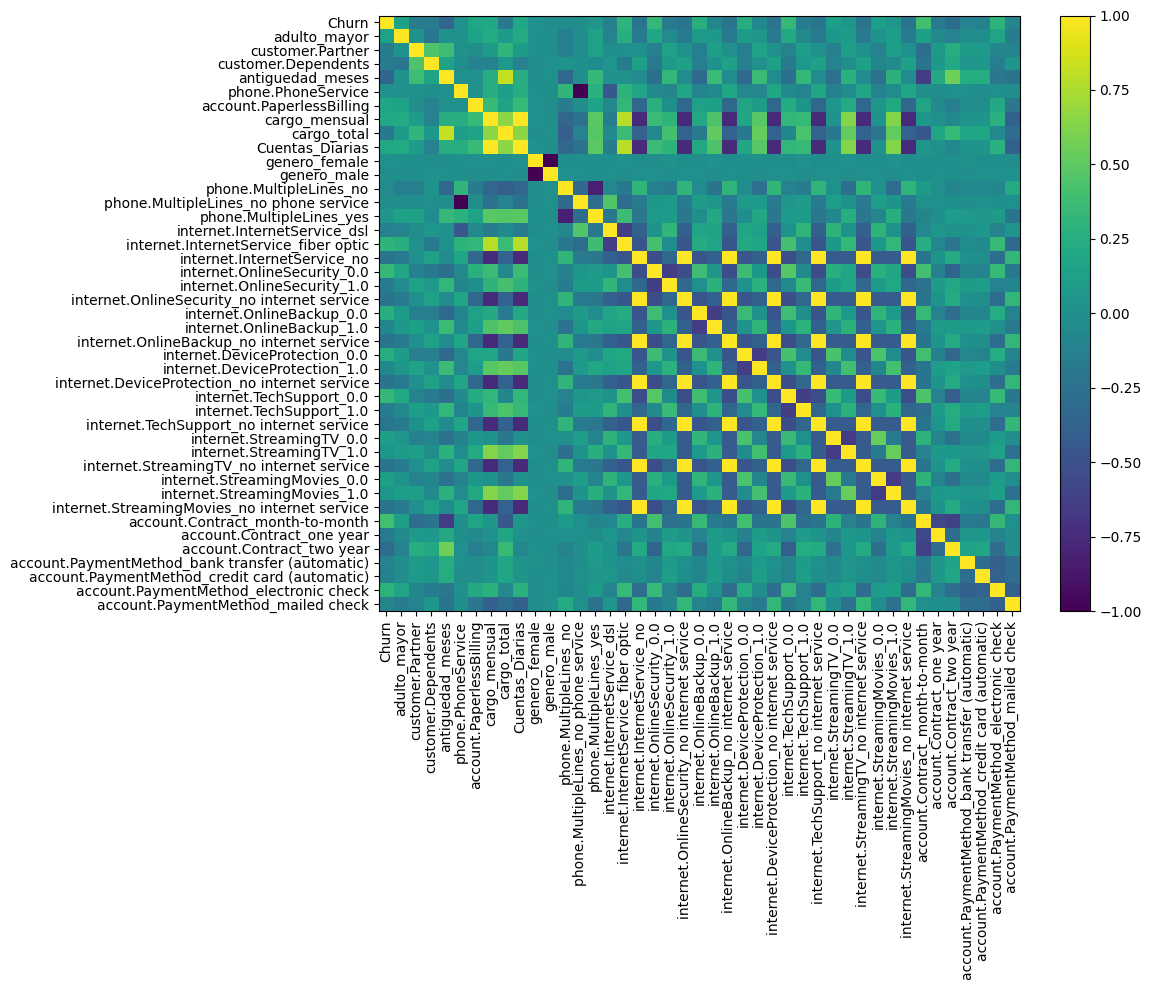

In [51]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

Tiempo de contrato x Cancelacion

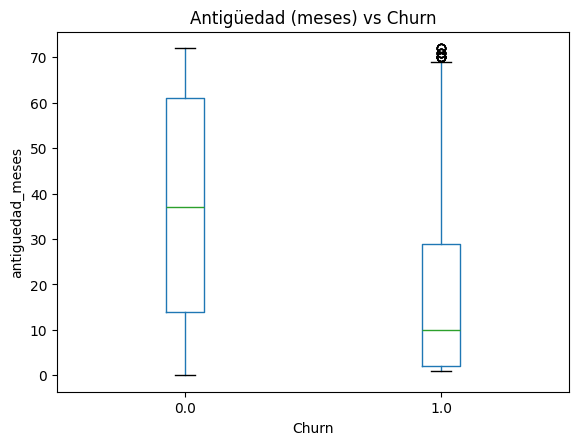

In [52]:
df.boxplot(column="antiguedad_meses", by="Churn", grid=False)
plt.title("Antigüedad (meses) vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("antiguedad_meses")
plt.show()

Gasto total x Cancelacion

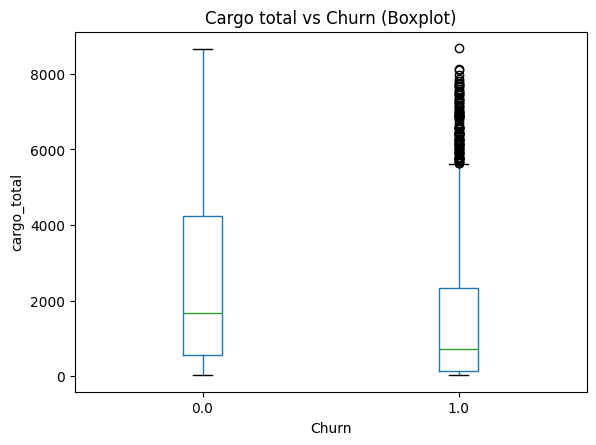

In [53]:
df.boxplot(column="cargo_total", by="Churn", grid=False)
plt.title("Cargo total vs Churn (Boxplot)")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("cargo_total")
plt.show()

Divicion de conjunto de datos

In [54]:
train = df.sample(frac=0.7, random_state=42)
test  = df.drop(train.index)

Creacion de Modelo

In [63]:
X_train = train.drop(columns=["Churn"])
y_train = train["Churn"]
X_test  = test.drop(columns=["Churn"])
y_test  = test["Churn"]

X_train = X_train.apply(pd.to_numeric, errors="coerce").fillna(0)
X_test  = X_test.apply(pd.to_numeric, errors="coerce").fillna(0)

log_reg = LogisticRegression(solver="liblinear", max_iter=2000, class_weight="balanced")
log_reg.fit(X_train, y_train)

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Evaluacion del modelo

In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --- Regresión Logística ---
y_pred_lr = log_reg.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-score :", f1_score(y_test, y_pred_lr))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))

# --- Árbol de Decisión ---
y_pred_tree = tree.predict(X_test)

print("\n=== Decision Tree ===")
print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall   :", recall_score(y_test, y_pred_tree))
print("F1-score :", f1_score(y_test, y_pred_tree))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_tree))

=== Logistic Regression ===
Accuracy : 0.7467889908256881
Precision: 0.49492671927846676
Recall   : 0.8084714548802947
F1-score : 0.6139860139860139
Confusion matrix:
 [[1189  448]
 [ 104  439]]

=== Decision Tree ===
Accuracy : 0.7298165137614679
Precision: 0.46229508196721314
Recall   : 0.5193370165745856
F1-score : 0.4891587163920208
Confusion matrix:
 [[1309  328]
 [ 261  282]]


ANALISIS


In [65]:
# ===== Regresión Logística: coeficientes (top variables) =====
coef_lr = pd.Series(log_reg.coef_[0], index=X_train.columns).sort_values(key=lambda s: s.abs(), ascending=False)
print("Top 15 (mayor impacto por |coef|):")
print(coef_lr.head(15))

# ===== Árbol de Decisión / Random Forest: importancia =====
imp_tree = pd.Series(tree.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 15 (importancia árbol):")
print(imp_tree.head(15))

Top 15 (mayor impacto por |coef|):
account.Contract_two year                -0.746596
account.Contract_month-to-month           0.730611
account.PaperlessBilling                  0.316893
internet.InternetService_fiber optic      0.282404
internet.InternetService_dsl             -0.273097
phone.MultipleLines_no                   -0.265880
phone.PhoneService                       -0.260853
account.PaymentMethod_electronic check    0.236224
internet.OnlineSecurity_0.0               0.220759
phone.MultipleLines_no phone service      0.217591
internet.OnlineSecurity_1.0              -0.211453
customer.Dependents                      -0.200085
account.PaymentMethod_mailed check       -0.188599
internet.TechSupport_0.0                  0.169353
internet.TechSupport_1.0                 -0.160047
dtype: float64

Top 15 (importancia árbol):
cargo_total                                        0.183439
account.Contract_month-to-month                    0.162870
cargo_mensual                       